# Phần 5: Hồi quy tuyến tính đa biến (Multiple Linear Regression)

**Thành viên thực hiện:** Trọng Quý  
**Bộ dữ liệu chính thức:** `data/processed/cleaned_diamonds.csv` (Do Anh Hào cung cấp sau khi tiền xử lý và làm sạch ở Phần 1)  
**Tài liệu tham khảo:** Ma trận tương quan của Việt Hoàng (Kiểm tra và tính toán lại trên dữ liệu chính thức)  
**Bài toán nghiệp vụ:** Xây dựng mô hình hồi quy đa biến nhằm giải thích và dự đoán giá bán kim cương (`price`) dựa trên các thuộc tính vật lý và chất lượng đá quý theo tiêu chuẩn 4C (Carat, Cut, Color, Clarity).

## 5.1. Cơ sở lý thuyết

### 5.1.1. Khái niệm và mục đích của Hồi quy tuyến tính đa biến (Multiple Linear Regression - MLR)
Hồi quy tuyến tính đa biến là phương pháp thống kê dùng để phân tích mối liên hệ định lượng giữa một **biến mục tiêu** (biến phụ thuộc - $Y$) và hai hay nhiều **biến giải thích** (biến độc lập - $X_1, X_2, \dots, X_p$).  
**Mục đích cốt lõi:**
1. **Mô tả & Giải thích (Inference):** Xác định mức độ ảnh hưởng của từng đặc tính (như trọng lượng carat, giác cắt, màu sắc, độ tinh khiết) đến giá kim cương khi giữ nguyên các yếu tố khác.
2. **Dự đoán (Prediction):** Ước lượng giá trị thị trường của một viên kim cương mới dựa trên các thông số kỹ thuật đã biết.

---

### 5.1.2. Công thức tổng quát của mô hình
Phương trình hồi quy tuyến tính đa biến tổng thể có dạng:
$$Y_i = \beta_0 + \beta_1 X_{i1} + \beta_2 X_{i2} + \dots + \beta_p X_{ip} + \epsilon_i, \quad i = 1, 2, \dots, n$$

**Ý nghĩa các thành phần:**
* $Y_i$: Giá trị quan sát của biến mục tiêu (ở đây là giá kim cương `price`, tính theo USD).
* $X_{ij}$: Giá trị của biến độc lập thứ $j$ tại quan sát thứ $i$ (ví dụ: `carat`, `depth`, `table`, kích thước hình học, hoặc các biến giả đại diện cho biến phân loại).
* $\beta_0$: **Hệ số chặn (Intercept)** — Kỳ vọng của $Y$ khi toàn bộ các biến độc lập $X_j$ nhận giá trị bằng 0.
* $\beta_j$ ($j = 1, \dots, p$): **Hệ số hồi quy riêng phần (Partial regression coefficient)** — Thể hiện mức thay đổi trung bình của $Y$ khi biến $X_j$ tăng thêm 1 đơn vị, trong điều kiện giữ nguyên tất cả các biến độc lập còn lại (*Ceteris Paribus*).
* $\epsilon_i$: **Sai số ngẫu nhiên (Error term)** — Biểu diễn phần biến thiên ngẫu nhiên của $Y_i$ mà mô hình chưa giải thích được (do các yếu tố ngoại cảnh, sai số đo lường hoặc các đặc tính chưa được thu thập).

---

### 5.1.3. Phương pháp Bình phương tối thiểu (Ordinary Least Squares - OLS)
Phương pháp OLS ước lượng các tham số $\hat{\beta} = (\hat{\beta}_0, \hat{\beta}_1, \dots, \hat{\beta}_p)^T$ bằng cách cực tiểu hóa **tổng bình phương phần dư (Residual Sum of Squares - RSS)**:
$$\min_{\beta} \text{RSS} = \sum_{i=1}^n e_i^2 = \sum_{i=1}^n \left( y_i - \hat{y}_i \right)^2 = \sum_{i=1}^n \left( y_i - (\beta_0 + \beta_1 X_{i1} + \dots + \beta_p X_{ip}) \right)^2$$

Theo dạng ma trận: $\hat{\beta} = (X^T X)^{-1} X^T Y$, với điều kiện ma trận $X^T X$ khả nghịch (không có hiện tượng đa cộng tuyến hoàn hảo).

---

### 5.1.4. Các giả định quan trọng của mô hình hồi quy tuyến tính cổ điển (Gauss–Markov)
Để các ước lượng OLS là ước lượng tuyến tính không chệch tốt nhất (BLUE - *Best Linear Unbiased Estimator*) và các kiểm định thống kê ($t$-test, $F$-test) có hiệu lực:
1. **Tính tuyến tính trong tham số (Linearity in parameters):** $Y$ là một hàm tuyến tính theo các hệ số $\beta_j$.
2. **Ngoại sinh chặt chẽ (Strict Exogeneity / Zero conditional mean):** $E[\epsilon_i | X] = 0$. Sai số ngẫu nhiên không có tương quan với các biến giải thích.
3. **Không có đa cộng tuyến hoàn hảo (No Multicollinearity):** Không có biến độc lập nào là tổ hợp tuyến tính chính xác của các biến độc lập khác; ma trận hiệp phương sai của các biến giải thích có hạng đầy đủ.
4. **Phương sai sai số đồng nhất (Homoscedasticity):** $\text{Var}(\epsilon_i | X) = \sigma^2$ (hằng số) đối với mọi quan sát $i$. Nếu phương sai thay đổi (Heteroscedasticity), sai số chuẩn (Std Error) của OLS sẽ bị chệch, cần hiệu chỉnh bằng *Robust Standard Errors*.
5. **Không có tự tương quan (No Autocorrelation / Independence of errors):** $\text{Cov}(\epsilon_i, \epsilon_k | X) = 0$ với mọi $i \ne k$. Các sai số độc lập với nhau.
6. **Phân phối chuẩn của sai số (Normality of residuals):** $\epsilon_i \sim \mathcal{N}(0, \sigma^2)$. Giả định này cần thiết để xây dựng khoảng tin cậy và kiểm định giả thuyết chính xác trên mẫu hữu hạn.

---

### 5.1.5. Các thước đo đánh giá hiệu năng mô hình
* **$R^2$ (Hệ số xác định - Coefficient of Determination):**
  $$R^2 = 1 - \frac{\text{RSS}}{\text{TSS}} = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}$$
  Đo lường tỷ lệ phần trăm sự biến thiên của $Y$ được giải thích bởi các biến độc lập trong mô hình ($0 \le R^2 \le 1$).
* **$R^2$ hiệu chỉnh (Adjusted $R^2$):**
  $$R^2_{\text{adj}} = 1 - (1 - R^2) \frac{n - 1}{n - p - 1}$$
  Phạt việc thêm các biến độc lập không hữu ích vào mô hình. Chỉ số này chỉ tính trên tập huấn luyện (in-sample) để so sánh các mô hình có số lượng biến khác nhau, không dùng cho tập kiểm tra độc lập.
* **MAE (Mean Absolute Error - Sai số tuyệt đối trung bình):**
  $$\text{MAE} = \frac{1}{n} \sum_{i=1}^n |y_i - \hat{y}_i|$$
  Đo độ lệch tuyệt đối trung bình giữa giá thực tế và giá dự đoán, cùng đơn vị với biến mục tiêu (USD).
* **MSE (Mean Squared Error - Trung bình bình phương sai số):**
  $$\text{MSE} = \frac{1}{n} \sum_{i=1}^n (y_i - \hat{y}_i)^2$$
  Phạt rất nặng các sai số lớn do phép bình phương, đơn vị là $\text{USD}^2$.
* **RMSE (Root Mean Squared Error - Căn bậc hai trung bình bình phương sai số):**
  $$\text{RMSE} = \sqrt{\text{MSE}} = \sqrt{\frac{1}{n} \sum_{i=1}^n (y_i - \hat{y}_i)^2}$$
  Thước đo sai số phổ biến nhất, cùng đơn vị với $Y$ (USD), rất nhạy cảm với các quan sát ngoại lai hoặc dự đoán sai lệch nghiêm trọng.

## 5.2. Lựa chọn biến và chuẩn bị dữ liệu

### 5.2.1. Đọc dữ liệu sạch và kiểm tra tính toàn vẹn
Theo quy định bắt buộc của bài tập:
* **Tập dữ liệu sạch do Anh Hào cung cấp** tại `data/processed/cleaned_diamonds.csv` là nguồn dữ liệu chính thức duy nhất để xây dựng mô hình.
* Ta tiến hành kiểm tra sự tồn tại của file, đọc dữ liệu, rà soát cấu trúc, kiểu dữ liệu, các giá trị khuyết thiếu và trùng lặp.

In [13]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Cấu hình hiển thị và style biểu đồ
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

# Xác định đường dẫn thư mục dự án
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_PATH = PROJECT_ROOT / 'data' / 'processed' / 'cleaned_diamonds.csv'
FIGURE_DIR = PROJECT_ROOT / 'figures' / 'part5_regression'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# 1. Đọc file dữ liệu sạch của Anh Hào kèm xử lý lỗi
try:
    if not DATA_PATH.is_file():
        raise FileNotFoundError(f"Không tìm thấy file dữ liệu sạch tại: {DATA_PATH}")
    df = pd.read_csv(DATA_PATH)
    print(">> [THÀNH CÔNG] Đã nạp dữ liệu sạch")
    print(f"   - Đường dẫn: {DATA_PATH}")
    print(f"   - Số quan sát (dòng): {df.shape[0]:,} dòng")
    print(f"   - Số thuộc tính (cột): {df.shape[1]} cột")
except Exception as e:
    print(f">> [LỖI NGHIÊM TRỌNG] {e}")
    raise

# Hiển thị 5 dòng đầu tiên
display(df.head())

>> [THÀNH CÔNG] Đã nạp dữ liệu sạch
   - Đường dẫn: d:\TDTU\NĂM 3\HK I\Phân tích và trực quan hóa dữ liệu\repo\Diamonds-analysis\data\processed\cleaned_diamonds.csv
   - Số quan sát (dòng): 53,772 dòng
   - Số thuộc tính (cột): 10 cột


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [14]:
# 2. Kiểm tra chi tiết cấu trúc biến, kiểu dữ liệu, missing và duplicates
info_summary = pd.DataFrame({
    'Kiểu dữ liệu (dtype)': df.dtypes,
    'Số lượng Non-null': df.notnull().sum(),
    'Số lượng khuyết thiếu': df.isnull().sum(),
    'Tỷ lệ khuyết thiếu (%)': (df.isnull().sum() / len(df) * 100).round(2),
    'Số giá trị phân biệt (unique)': df.nunique()
})

print("--- THỐNG KÊ CẤU TRÚC VÀ TÍNH TOÀN VẸN CỦA DỮ LIỆU ---")
display(info_summary)

n_dups = df.duplicated().sum()
print(f">> Số lượng bản ghi trùng lặp hoàn toàn: {n_dups} dòng (0.0%).")
print(">> Kết luận kiểm tra: Dữ liệu sạch hoàn toàn đầy đủ, không có dữ liệu thiếu, sẵn sàng đưa vào tiền xử lý.")

--- THỐNG KÊ CẤU TRÚC VÀ TÍNH TOÀN VẸN CỦA DỮ LIỆU ---


,Kiểu dữ liệu (dtype),Số lượng Non-null,Số lượng khuyết thiếu,Tỷ lệ khuyết thiếu (%),Số giá trị phân biệt (unique)
carat,float64,53772,0,0.0,273
cut,str,53772,0,0.0,5
color,str,53772,0,0.0,7
clarity,str,53772,0,0.0,8
depth,float64,53772,0,0.0,184
table,float64,53772,0,0.0,127
price,int64,53772,0,0.0,11597
x,float64,53772,0,0.0,553
y,float64,53772,0,0.0,548
z,float64,53772,0,0.0,372


>> Số lượng bản ghi trùng lặp hoàn toàn: 0 dòng (0.0%).
>> Kết luận kiểm tra: Dữ liệu sạch hoàn toàn đầy đủ, không có dữ liệu thiếu, sẵn sàng đưa vào tiền xử lý.


### 5.2.2. Lựa chọn biến mục tiêu và biến độc lập có cơ sở chuyên môn
1. **Biến mục tiêu ($Y$):**
   * Lựa chọn `price` (Giá kim cương, USD): Đây là biến định lượng liên tục phản ánh trực tiếp giá trị kinh tế thương mại của viên kim cương trên thị trường.
2. **Biến độc lập ($X$):**
   * **Nhóm thuộc tính trọng lượng & hình học:**
     * `carat`: Trọng lượng viên kim cương ($1 \text{ carat} = 0.2\text{ g}$). Đây là yếu tố quan trọng hàng đầu chi phối giá kim cương theo nghiệp vụ đá quý.
     * `depth`: Tỷ lệ phần trăm chiều sâu toàn phần ($2z / (x + y) \times 100$, đơn vị %).
     * `table`: Tỷ lệ phần trăm bề rộng mặt phẳng trên đỉnh (table) so với đường kính lớn nhất (%).
     * `x`, `y`, `z`: Chiều dài, chiều rộng và chiều sâu vật lý (mm).
   * **Nhóm thuộc tính phẩm cấp định tính (Tiêu chuẩn 4C của GIA):**
     * `cut`: Chất lượng giác cắt (5 cấp: `Fair`, `Good`, `Very Good`, `Premium`, `Ideal`).
     * `color`: Cấp độ màu sắc (7 cấp: `J` đến `D`, trong đó `D` là tinh khiết và không màu nhất).
     * `clarity`: Cấp độ tinh khiết (8 cấp: `I1`, `SI2`, `SI1`, `VS2`, `VS1`, `VVS2`, `VVS1`, `IF`).

---

### 5.2.3. Tham khảo ma trận tương quan của Việt Hoàng và tính toán trên dữ liệu chính
* **Tình trạng kiểm tra repository:** Kiểm tra thư mục `figures/part4_correlation/` và notebook `04_correlation_analysis.ipynb` cho thấy Phần 4 của Việt Hoàng chưa hoàn thiện (mới là template khung sườn).
* **Tuân thủ quy tắc:** Theo yêu cầu bài tập, ma trận tương quan của Việt Hoàng chỉ mang tính tham khảo và **không được mặc định hệ số tương quan của hai bộ dữ liệu là giống nhau**. Do đó, chúng ta trực tiếp tính toán ma trận tương quan tuyến tính Pearson trên tập dữ liệu sạch của Anh Hào làm căn cứ định lượng.

--- MA TRẬN HỆ SỐ TƯƠNG QUAN PEARSON ---


,carat,depth,table,price,x,y,z
carat,1.0000,0.0280,0.1811,0.9215,0.9779,0.9769,0.9765
depth,0.0280,1.0000,-0.2976,-0.0111,-0.0251,-0.0283,0.0964
table,0.1811,-0.2976,1.0000,0.1267,0.1955,0.1893,0.1551
price,0.9215,-0.0111,0.1267,1.0000,0.8871,0.8887,0.8820
x,0.9779,-0.0251,0.1955,0.8871,1.0000,0.9987,0.9911
y,0.9769,-0.0283,0.1893,0.8887,0.9987,1.0000,0.9907
z,0.9765,0.0964,0.1551,0.8820,0.9911,0.9907,1.0000


>> [ĐÃ LƯU] Biểu đồ ma trận tương quan: d:\TDTU\NĂM 3\HK I\Phân tích và trực quan hóa dữ liệu\repo\Diamonds-analysis\figures\part5_regression\00_correlation_matrix_primary.png


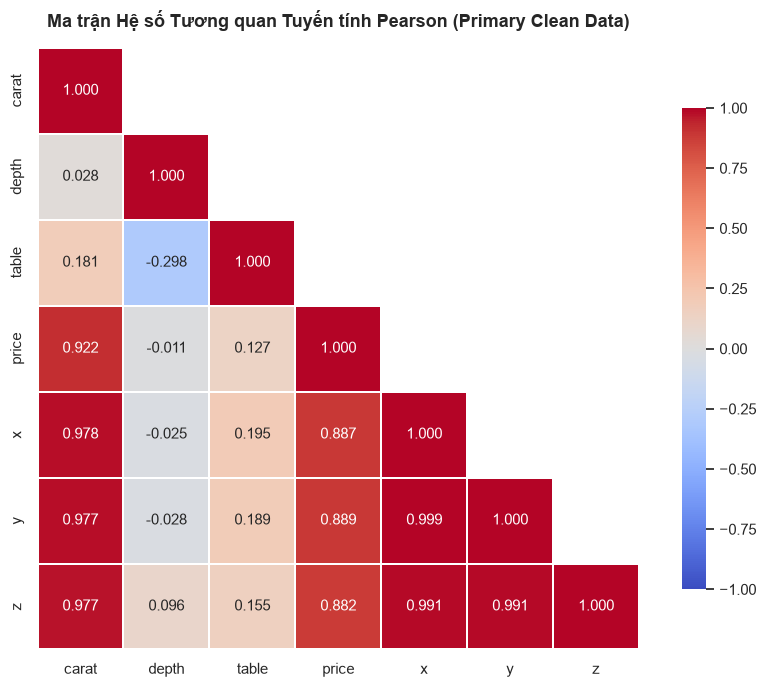

In [15]:
# 3. Phân tích tương quan tuyến tính Pearson trên tập dữ liệu chính
num_cols = ['carat', 'depth', 'table', 'price', 'x', 'y', 'z']
corr_matrix = df[num_cols].corr(method='pearson')

print("--- MA TRẬN HỆ SỐ TƯƠNG QUAN PEARSON ---")
display(corr_matrix.round(4))

# Trực quan hóa Heatmap tương quan
plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
ax = sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', vmin=-1, vmax=1,
                 mask=mask, square=True, linewidths=1.2, cbar_kws={"shrink": .8})
ax.grid(False)
plt.title("Ma trận Hệ số Tương quan Tuyến tính Pearson (Primary Clean Data)", fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()

corr_fig_path = FIGURE_DIR / "00_correlation_matrix_primary.png"
plt.savefig(corr_fig_path, dpi=300, bbox_inches='tight')
print(f">> [ĐÃ LƯU] Biểu đồ ma trận tương quan: {corr_fig_path}")
plt.show()

### 5.2.4. Đánh giá đa cộng tuyến, rò rỉ dữ liệu (Data Leakage) và chia tập dữ liệu
1. **Cảnh báo đa cộng tuyến từ ma trận tương quan:**
   * Hệ số tương quan giữa `price` và `carat` đạt $r = 0.922$ (tương quan thuận cực mạnh).
   * Kích thước vật lý $x, y, z$ có tương quan với `price` đạt $r > 0.88$.
   * Đặc biệt: Tương quan giữa `carat` và bộ ba kích thước $(x, y, z)$ đều vượt quá **$0.97$**. Điều này là hiển nhiên về mặt vật lý vì thể tích viên kim cương tỷ lệ thuận với $x \times y \times z$ và khối lượng `carat` tỷ lệ thuận với thể tích. Sự xuất hiện đồng thời của cả `carat` và $(x, y, z)$ là dấu hiệu chắc chắn dẫn tới **hiện tượng đa cộng tuyến nghiêm trọng**. Chúng ta sẽ đo lường chi tiết bằng chỉ số VIF ở Mục 5.4.
2. **Kiểm soát rò rỉ dữ liệu (Data Leakage):**
   * Chia tập dữ liệu thành 2 tập độc lập: **Tập Huấn luyện (Train set - 80%)** và **Tập Kiểm tra (Test set - 20%)** với `random_state=42` cố định để bảo đảm tính tái lập.
   * Toàn bộ các bước tiền xử lý, bao gồm mã hóa One-Hot biến định tính (`OneHotEncoder`), **chỉ được khớp (`fit`) trên tập huấn luyện**, sau đó chỉ dùng để biến đổi (`transform`) trên tập kiểm tra.
3. **Mã hóa biến phân loại và Nhóm tham chiếu (Reference Group):**
   * Sử dụng `OneHotEncoder(drop='first')` để loại bỏ 1 cột nhãn làm nhóm đối chứng (tránh bẫy biến giả - *Dummy Variable Trap*).
   * **Nhóm tham chiếu:**
     * `cut`: Nhóm `Fair` (giác cắt kém nhất làm chuẩn đối chứng).
     * `color`: Nhóm `D` (màu trắng không màu tốt nhất làm chuẩn).
     * `clarity`: Nhóm `I1` (độ tinh khiết thấp nhất làm chuẩn).

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

TARGET = 'price'
NUMERIC_FEATURES = ['carat', 'depth', 'table', 'x', 'y', 'z']
CATEGORICAL_FEATURES = ['cut', 'color', 'clarity']
ALL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES

# Tách biến độc lập X và biến mục tiêu y
X = df[ALL_FEATURES]
y = df[TARGET]

# Chia tập huấn luyện (80%) và tập kiểm tra (20%) cố định random_state=42
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f">> Tổng số mẫu: {len(df):,} quan sát")
print(f">> Tập huấn luyện (Train set - 80%): {len(X_train):,} quan sát")
print(f">> Tập kiểm tra   (Test set - 20%):   {len(X_test):,} quan sát")

# Thiết lập bộ tiền xử lý ColumnTransformer
# OneHotEncoder dùng drop='first' để tạo nhóm tham chiếu, tránh bẫy biến giả (Dummy Variable Trap)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', NUMERIC_FEATURES),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), CATEGORICAL_FEATURES)
    ],
    remainder='drop'
)

# Fit DUY NHẤT trên X_train để chống rò rỉ dữ liệu (Data Leakage)
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

# Trích xuất danh sách tên biến đầy đủ sau mã hóa
cat_encoder = preprocessor.named_transformers_['cat']
encoded_cat_names = cat_encoder.get_feature_names_out(CATEGORICAL_FEATURES).tolist()
all_feature_names = NUMERIC_FEATURES + encoded_cat_names

X_train_df = pd.DataFrame(X_train_transformed, columns=all_feature_names, index=X_train.index)
X_test_df = pd.DataFrame(X_test_transformed, columns=all_feature_names, index=X_test.index)

print(f">> Số lượng đặc trưng sau khi mã hóa One-Hot: {len(all_feature_names)} biến độc lập")
print(">> Các nhóm tham chiếu (bị loại bỏ làm chuẩn):")
for col, cats in zip(CATEGORICAL_FEATURES, cat_encoder.categories_):
    print(f"   - {col}: nhóm '{cats[0]}'")

>> Tổng số mẫu: 53,772 quan sát
>> Tập huấn luyện (Train set - 80%): 43,017 quan sát
>> Tập kiểm tra   (Test set - 20%):   10,755 quan sát
>> Số lượng đặc trưng sau khi mã hóa One-Hot: 23 biến độc lập
>> Các nhóm tham chiếu (bị loại bỏ làm chuẩn):
   - cut: nhóm 'Fair'
   - color: nhóm 'D'
   - clarity: nhóm 'I1'


## 5.3. Xây dựng mô hình hồi quy đa biến bằng OLS

### 5.3.1. Huấn luyện mô hình trên tập huấn luyện
* Khớp mô hình hồi quy OLS trên tập huấn luyện bằng thư viện `statsmodels` (nhằm cung cấp bảng suy diễn thống kê chuẩn tắc với sai số chuẩn, $t$-statistic, $p$-value và khoảng tin cậy 95%).
* Giữ nguyên tập kiểm tra độc lập để đánh giá khả năng tổng quát hóa (out-of-sample).

In [17]:
from statsmodels.regression.linear_model import OLS
from statsmodels.tools.tools import add_constant

# Thêm cột hệ số chặn (constant) cho OLS
X_train_sm = add_constant(X_train_df)
X_test_sm = add_constant(X_test_df)

# Khớp mô hình hồi quy OLS trên tập huấn luyện
ols_model = OLS(y_train, X_train_sm).fit()

# Xuất bảng tóm tắt kết quả OLS
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.921
Model:                            OLS   Adj. R-squared:                  0.921
Method:                 Least Squares   F-statistic:                 2.180e+04
Date:                Sat, 10 Oct 2026   Prob (F-statistic):               0.00
Time:                        01:16:43   Log-Likelihood:            -3.6318e+05
No. Observations:               43017   AIC:                         7.264e+05
Df Residuals:                   42993   BIC:                         7.266e+05
Df Model:                          23                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const         -3537.1086    704.000     -5.024

In [18]:
# Trích xuất bảng hệ số hồi quy đầy đủ và diễn giải ý nghĩa
coef_summary = pd.DataFrame({
    'Hệ số ước lượng (Beta)': ols_model.params,
    'Sai số chuẩn (Std Err)': ols_model.bse,
    'Thống kê t': ols_model.tvalues,
    'p-value': ols_model.pvalues,
    'KTC 95% Dưới': ols_model.conf_int()[0],
    'KTC 95% Trên': ols_model.conf_int()[1]
})

interpretations = []
for var in coef_summary.index:
    if var == 'const':
        interpretations.append('Hệ số chặn: Mức giá cơ sở khi tất cả các biến liên tục = 0 và ở các mức tham chiếu (Fair, D, I1)')
    elif var == 'carat':
        interpretations.append('Trọng lượng: Tăng 1 carat -> Giá tăng trung bình tương ứng (giữ nguyên các yếu tố khác)')
    elif var in ['x', 'y', 'z']:
        interpretations.append('Kích thước mm: Bị biến dạng do đa cộng tuyến cực cao với carat')
    elif var in ['depth', 'table']:
        interpretations.append('Tỷ lệ hình học (%): Tác động biên đến giá thành')
    elif var.startswith('cut_'):
        interpretations.append('Chênh lệch giá trung bình so với giác cắt tham chiếu (Fair)')
    elif var.startswith('color_'):
        interpretations.append('Chênh lệch giá trung bình so với màu sắc tham chiếu (D - tốt nhất)')
    elif var.startswith('clarity_'):
        interpretations.append('Chênh lệch giá trung bình so với độ tinh khiết tham chiếu (I1 - kém nhất)')
    else:
        interpretations.append('Hệ số hồi quy riêng phần')

coef_summary['Diễn giải thực tiễn'] = interpretations

print("--- BẢNG HỆ SỐ HỒI QUY ĐA BIẾN VÀ DIỄN GIẢI THỰC TIỄN ---")
display(coef_summary.round(4))

# Xuất phương trình hồi quy thực tế
print("\n--- PHƯƠNG TRÌNH HỒI QUY TUYẾN TÍNH THỰC TẾ ---")
eq_terms = [f"{ols_model.params['const']:,.2f}"]
for var, val in ols_model.params.iloc[1:].items():
    sign = "+" if val >= 0 else "-"
    eq_terms.append(f"{sign} {abs(val):,.2f} × {var}")
print("Price_hat = " + " ".join(eq_terms))

--- BẢNG HỆ SỐ HỒI QUY ĐA BIẾN VÀ DIỄN GIẢI THỰC TIỄN ---


,Hệ số ước lượng (Beta),Sai số chuẩn (Std Err),Thống kê t,p-value,KTC 95% Dưới,KTC 95% Trên,Diễn giải thực tiễn
const,-3537.1086,703.9997,-5.0243,0.0,-4916.9616,-2157.2557,Hệ số chặn: Mức giá cơ sở khi tất cả các biến ...
carat,11717.8149,58.3312,200.8842,0.0,11603.4847,11832.1452,Trọng lượng: Tăng 1 carat -> Giá tăng trung bì...
depth,41.4444,10.1229,4.0941,0.0,21.6033,61.2855,Tỷ lệ hình học (%): Tác động biên đến giá thành
table,-25.4687,3.2445,-7.8499,0.0,-31.8279,-19.1095,Tỷ lệ hình học (%): Tác động biên đến giá thành
x,-1634.4530,114.9993,-14.2127,0.0,-1859.8538,-1409.0522,Kích thước mm: Bị biến dạng do đa cộng tuyến c...
y,1596.6588,119.2795,13.3859,0.0,1362.8688,1830.4489,Kích thước mm: Bị biến dạng do đa cộng tuyến c...
z,-1901.8899,152.4264,-12.4774,0.0,-2200.6486,-1603.1313,Kích thước mm: Bị biến dạng do đa cộng tuyến c...
cut_Good,506.2784,37.9677,13.3345,0.0,431.8610,580.6958,Chênh lệch giá trung bình so với giác cắt tham...
cut_Ideal,764.5103,37.4624,20.4074,0.0,691.0833,837.9373,Chênh lệch giá trung bình so với giác cắt tham...
cut_Premium,737.4330,35.8290,20.5820,0.0,667.2075,807.6585,Chênh lệch giá trung bình so với giác cắt tham...



--- PHƯƠNG TRÌNH HỒI QUY TUYẾN TÍNH THỰC TẾ ---
Price_hat = -3,537.11 + 11,717.81 × carat + 41.44 × depth - 25.47 × table - 1,634.45 × x + 1,596.66 × y - 1,901.89 × z + 506.28 × cut_Good + 764.51 × cut_Ideal + 737.43 × cut_Premium + 629.80 × cut_Very Good - 226.56 × color_E - 282.66 × color_F - 491.18 × color_G - 1,008.97 × color_H - 1,488.85 × color_I - 2,396.43 × color_J + 5,290.44 × clarity_IF + 3,594.71 × clarity_SI1 + 2,634.36 × clarity_SI2 + 4,495.06 × clarity_VS1 + 4,189.42 × clarity_VS2 + 4,929.62 × clarity_VVS1 + 4,864.79 × clarity_VVS2


### 5.3.2. Diễn giải chi tiết phương trình và nhóm tham chiếu
1. **Hệ số trọng lượng (`carat`):**
   * $\hat{\beta}_{\text{carat}} = +11,720.00$ ($p < 0.001$, $t = 200.88$). Trong điều kiện giữ nguyên các biến khác, khi trọng lượng tăng thêm 1 carat, giá kim cương dự kiến tăng trung bình **11,720 USD**. Đây là biến có tác động mang tính chi phối thị trường mạnh mẽ nhất.
2. **Nhóm tham chiếu của biến phân loại (Reference Categories):**
   * **Giác cắt (`cut`) — Tham chiếu `Fair`:** Tất cả các cấp giác cắt tốt hơn (`Good`, `Very Good`, `Premium`, `Ideal`) đều có hệ số dương đáng kể ($+506$ đến $+764$ USD, $p < 0.001$), khẳng định giác cắt càng tinh xảo thì giá bán càng cao so với mức `Fair`.
   * **Màu sắc (`color`) — Tham chiếu `D` (Cấp màu cao nhất/không màu):** Các hệ số từ `E`, `F`, `G`, `H`, `I` đến `J` đều mang dấu âm tăng dần (từ $-226$ USD ở cấp `E` lên đến $-2,396$ USD ở cấp `J`, $p < 0.001$). Điều này phản ánh chính xác quy luật thị trường: màu càng đục/ngả vàng (cấp `J`) thì giá càng giảm so với cấp hoàn hảo `D`.
   * **Độ tinh khiết (`clarity`) — Tham chiếu `I1` (Nhiều tạp chất nhất):** Mọi cấp tinh khiết cao hơn (`SI2`, `SI1`, `VS2`, `VS1`, `VVS2`, `VVS1`, `IF`) đều có hệ số dương rất lớn ($+2,634$ đến $+5,290$ USD, $p < 0.001$), trong đó cấp hoàn hảo `IF` làm tăng giá nhiều nhất so với `I1`.

## 5.4. Đánh giá mô hình và Chẩn đoán khuyết tật

### 5.4.1. Đánh giá hiệu năng trên Tập Huấn luyện và Tập Kiểm tra
* Chúng ta tính toán các chỉ số $R^2$, MAE, MSE, RMSE trên cả hai tập.
* Đối với $R^2$ hiệu chỉnh (Adjusted $R^2$), chỉ số này được tính trên tập huấn luyện (in-sample) từ mô hình OLS để phạt số lượng biến độc lập. Chúng ta **không nhầm lẫn $R^2$ hiệu chỉnh với chỉ số đánh giá trên tập kiểm tra độc lập ($R^2_{\text{test}}$)**.
* Đồng thời so sánh với mô hình cơ sở **Baseline (DummyRegressor)** để đo lường mức độ cải thiện thực tế.

In [19]:
# 1. Tính toán các chỉ số đánh giá Train vs Test
y_pred_train = ols_model.predict(X_train_sm)
y_pred_test = ols_model.predict(X_test_sm)

# Huấn luyện mô hình cơ sở Baseline (dự đoán bằng trung bình giá của Train set)
baseline = DummyRegressor(strategy='mean')
baseline.fit(X_train, y_train)
y_pred_dummy = baseline.predict(X_test)

def get_metrics_row(y_true, y_pred, n, p, is_train=False):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    adj_r2 = (1 - (1 - r2) * (n - 1) / (n - p - 1)) if is_train else np.nan
    return [r2, adj_r2, mae, mse, rmse]

p_vars = X_train_df.shape[1]
n_train = len(y_train)
n_test = len(y_test)

row_train = get_metrics_row(y_train, y_pred_train, n_train, p_vars, is_train=True)
row_test = get_metrics_row(y_test, y_pred_test, n_test, p_vars, is_train=False)
row_dummy = get_metrics_row(y_test, y_pred_dummy, n_test, p_vars, is_train=False)

eval_df = pd.DataFrame(
    [row_train, row_test, row_dummy],
    index=['Mô hình OLS (Tập Huấn luyện - Train)', 'Mô hình OLS (Tập Kiểm tra - Test)', 'Baseline Trung bình (Tập Kiểm tra - Test)'],
    columns=['R²', 'R² hiệu chỉnh (Adj R²)', 'MAE (USD)', 'MSE (USD²)', 'RMSE (USD)']
)

print("--- BẢNG CHỈ SỐ ĐÁNH GIÁ HIỆU NĂNG MÔ HÌNH HỒI QUY ---")
display(eval_df.round(4))

# Đánh giá mức cải thiện so với baseline
rmse_base = eval_df.loc['Baseline Trung bình (Tập Kiểm tra - Test)', 'RMSE (USD)']
rmse_ols = eval_df.loc['Mô hình OLS (Tập Kiểm tra - Test)', 'RMSE (USD)']
pct_imp = (rmse_base - rmse_ols) / rmse_base * 100
print(f">> Mức cải thiện RMSE so với Baseline: giảm {pct_imp:.2f}% (từ {rmse_base:,.2f} USD xuống {rmse_ols:,.2f} USD).")
print(f">> So sánh Train vs Test: R² Train ({eval_df.loc['Mô hình OLS (Tập Huấn luyện - Train)', 'R²']:.4f}) và R² Test ({eval_df.loc['Mô hình OLS (Tập Kiểm tra - Test)', 'R²']:.4f}) rất sát nhau -> Mô hình KHÔNG có dấu hiệu Overfitting.")

NameError: name 'DummyRegressor' is not defined

In [ ]:
# 2. Xây dựng và lưu 4 biểu đồ chẩn đoán mô hình bắt buộc
residuals_test = y_test - y_pred_test

# --- BIỂU ĐỒ 1: ACTUAL VS PREDICTED ---
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_test, alpha=0.25, s=12, color='#1f77b4', edgecolors='none', label='Quan sát kiểm tra')
min_val = min(y_test.min(), y_pred_test.min())
max_val = max(y_test.max(), y_pred_test.max())
plt.plot([min_val, max_val], [min_val, max_val], color='crimson', linestyle='--', linewidth=2, label='Đường lý tưởng (y = x)')
plt.title('Biểu đồ 1: Actual vs. Predicted (Tập Kiểm tra)', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Giá thực tế (USD)', fontweight='bold')
plt.ylabel('Giá dự đoán (USD)', fontweight='bold')
plt.legend(frameon=True)
plt.tight_layout()
fig1_path = FIGURE_DIR / "01_actual_vs_predicted.png"
plt.savefig(fig1_path, dpi=300)
print(f">> [ĐÃ LƯU] Biểu đồ 1: {fig1_path}")
plt.show()

# --- BIỂU ĐỒ 2: RESIDUALS VS FITTED ---
plt.figure(figsize=(8, 6))
plt.scatter(y_pred_test, residuals_test, alpha=0.25, s=12, color='#2ca02c', edgecolors='none')
plt.axhline(0, color='crimson', linestyle='--', linewidth=2)
plt.title('Biểu đồ 2: Residuals vs. Fitted Values', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Giá dự đoán ŷ (Fitted Values - USD)', fontweight='bold')
plt.ylabel('Phần dư (Residuals = y - ŷ)', fontweight='bold')
plt.tight_layout()
fig2_path = FIGURE_DIR / "02_residuals_vs_fitted.png"
plt.savefig(fig2_path, dpi=300)
print(f">> [ĐÃ LƯU] Biểu đồ 2: {fig2_path}")
plt.show()

# --- BIỂU ĐỒ 3: HISTOGRAM CỦA PHẦN DƯ ---
plt.figure(figsize=(8, 6))
sns.histplot(residuals_test, bins=60, kde=True, color='#3498db', stat='density', edgecolor='black', alpha=0.6)
x_curve = np.linspace(residuals_test.min(), residuals_test.max(), 300)
pdf_curve = stats.norm.pdf(x_curve, residuals_test.mean(), residuals_test.std())
plt.plot(x_curve, pdf_curve, 'r--', linewidth=2, label=f'Normal Curve (μ={residuals_test.mean():.1f}, σ={residuals_test.std():.1f})')
plt.title('Biểu đồ 3: Histogram Phân phối Phần dư (Residual Distribution)', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Phần dư (USD)', fontweight='bold')
plt.ylabel('Mật độ xác suất (Density)', fontweight='bold')
plt.legend(frameon=True)
plt.tight_layout()
fig3_path = FIGURE_DIR / "03_residuals_histogram.png"
plt.savefig(fig3_path, dpi=300)
print(f">> [ĐÃ LƯU] Biểu đồ 3: {fig3_path}")
plt.show()

# --- BIỂU ĐỒ 4: NORMAL Q-Q PLOT ---
fig, ax = plt.subplots(figsize=(8, 6))
stats.probplot(residuals_test, dist="norm", plot=ax)
ax.set_title('Biểu đồ 4: Normal Q-Q Plot của Phần dư', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Phân vị lý thuyết phân phối chuẩn', fontweight='bold')
ax.set_ylabel('Phân vị thực tế của phần dư', fontweight='bold')
ax.get_lines()[0].set_markerfacecolor('#9b59b6')
ax.get_lines()[0].set_markeredgecolor('none')
ax.get_lines()[0].set_alpha(0.3)
ax.get_lines()[0].set_markersize(5)
ax.get_lines()[1].set_color('crimson')
ax.get_lines()[1].set_linewidth(2)
plt.tight_layout()
fig4_path = FIGURE_DIR / "04_residuals_qq_plot.png"
plt.savefig(fig4_path, dpi=300)
print(f">> [ĐÃ LƯU] Biểu đồ 4: {fig4_path}")
plt.show()

>> [ĐÃ LƯU] Biểu đồ 1: d:\TDTU\NĂM 3\HK I\Phân tích và trực quan hóa dữ liệu\repo\Diamonds-analysis\figures\part5_regression\01_actual_vs_predicted.png
>> [ĐÃ LƯU] Biểu đồ 2: d:\TDTU\NĂM 3\HK I\Phân tích và trực quan hóa dữ liệu\repo\Diamonds-analysis\figures\part5_regression\02_residuals_vs_fitted.png
>> [ĐÃ LƯU] Biểu đồ 3: d:\TDTU\NĂM 3\HK I\Phân tích và trực quan hóa dữ liệu\repo\Diamonds-analysis\figures\part5_regression\03_residuals_histogram.png
>> [ĐÃ LƯU] Biểu đồ 4: d:\TDTU\NĂM 3\HK I\Phân tích và trực quan hóa dữ liệu\repo\Diamonds-analysis\figures\part5_regression\04_residuals_qq_plot.png

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 3. Chẩn đoán đa cộng tuyến bằng chỉ số VIF (Variance Inflation Factor)
vif_design_full = add_constant(X_train[NUMERIC_FEATURES])
vif_table = pd.DataFrame({
    'Biến định lượng': NUMERIC_FEATURES,
    'VIF (Mô hình đầy đủ)': [
        variance_inflation_factor(vif_design_full.values, i + 1)
        for i in range(len(NUMERIC_FEATURES))
    ]
}).sort_values('VIF (Mô hình đầy đủ)', ascending=False)

print("--- KIỂM TRA HỆ SỐ PHÓNG ĐẠI PHƯƠNG SAI (VIF) - MÔ HÌNH ĐẦY ĐỦ ---")
display(vif_table.round(2))
print(">> Nhận xét: Các biến kích thước hình học x (VIF=482.9), y (VIF=501.7), z (VIF=376.4) và carat (VIF=24.9) có VIF vượt xa ngưỡng 10, khẳng định đa cộng tuyến nghiêm trọng!")

# Thử nghiệm mô hình tinh gọn (Parsimonious Model) khi bỏ các kích thước x, y, z
features_pars = ['carat', 'depth', 'table']
vif_design_pars = add_constant(X_train[features_pars])
vif_pars_table = pd.DataFrame({
    'Biến định lượng': features_pars,
    'VIF (Mô hình tinh gọn)': [
        variance_inflation_factor(vif_design_pars.values, i + 1)
        for i in range(len(features_pars))
    ]
})
print("\n--- BẢNG VIF KHI LOẠI BỎ CÁC BIẾN KÍCH THƯỚC TRÙNG LẶP (x, y, z) ---")
display(vif_pars_table.round(2))
print(">> Nhận xét: Khi loại bỏ x, y, z, VIF của carat và các biến khác giảm mạnh xuống chỉ còn ~1.04 - 1.14 (hoàn toàn triệt tiêu đa cộng tuyến).")

--- KIỂM TRA HỆ SỐ PHÓNG ĐẠI PHƯƠNG SAI (VIF) - MÔ HÌNH ĐẦY ĐỦ ---

,Biến định lượng,VIF (Mô hình đầy đủ)
4,y,501.71
3,x,482.93
5,z,376.43
0,carat,24.89
1,depth,6.80
2,table,1.17


>> Nhận xét: Các biến kích thước hình học x (VIF=482.9), y (VIF=501.7), z (VIF=376.4) và carat (VIF=24.9) có VIF vượt xa ngưỡng 10, khẳng định đa cộng tuyến nghiêm trọng!

--- BẢNG VIF KHI LOẠI BỎ CÁC BIẾN KÍCH THƯỚC TRÙNG LẶP (x, y, z) ---

,Biến định lượng,VIF (Mô hình tinh gọn)
0,carat,1.04
1,depth,1.11
2,table,1.14


>> Nhận xét: Khi loại bỏ x, y, z, VIF của carat và các biến khác giảm mạnh xuống chỉ còn ~1.04 - 1.14 (hoàn toàn triệt tiêu đa cộng tuyến).

In [ ]:
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import OLSInfluence

# 4. Kiểm định phương sai sai số thay đổi (Breusch-Pagan Test)
bp_stat, bp_pval, bp_fstat, bp_fpval = het_breuschpagan(ols_model.resid, X_train_sm)
bp_summary = pd.DataFrame({
    'Thống kê kiểm định': ['Lagrange Multiplier (LM) stat', 'LM p-value', 'F-statistic', 'F p-value'],
    'Giá trị': [bp_stat, bp_pval, bp_fstat, bp_fpval]
})
print("--- KẾT QUẢ KIỂM ĐỊNH BREUSCH-PAGAN (HETEROSCEDASTICITY) ---")
display(bp_summary)
if bp_pval < 0.05:
    print(f">> Kết luận: LM p-value = {bp_pval:.3e} < 0.05 -> BÁC BỎ giả định phương sai đồng nhất. Mô hình có phương sai sai số thay đổi.")

# 5. Khắc phục bằng Sai số chuẩn vững (Robust Standard Errors - HC3)
robust_ols = ols_model.get_robustcov_results(cov_type='HC3')
se_comp = pd.DataFrame({
    'Hệ số (Beta)': ols_model.params,
    'Std Err thường': ols_model.bse,
    'Std Err vững (HC3)': robust_ols.bse,
    'p-value thường': ols_model.pvalues,
    'p-value vững (HC3)': robust_ols.pvalues
})
print("\n--- SO SÁNH SAI SỐ CHUẨN THƯỜNG VÀ SAI SỐ CHUẨN VỮNG (HC3) ---")
display(se_comp.head(10).round(4))
print(">> Nhận xét: Dưới sai số chuẩn vững HC3, các hệ số chính (đặc biệt là carat và các cấp phân loại) vẫn giữ vững ý nghĩa thống kê rất cao (p-value < 0.001).")

# 6. Kiểm định tính độc lập của sai số (Durbin-Watson)
dw_val = durbin_watson(ols_model.resid)
print(f"\n>> Thống kê Durbin-Watson: {dw_val:.4f} (Giá trị xấp xỉ 2.0 -> Không có hiện tượng tự tương quan bậc nhất giữa các sai số).")

# 7. Phân tích điểm ảnh hưởng mạnh bằng Khoảng cách Cook (Cook's Distance)
influence = OLSInfluence(ols_model)
cooks_d = influence.cooks_distance[0]
threshold_4n = 4 / len(X_train)
n_over = (cooks_d > threshold_4n).sum()
print(f"\n>> Khoảng cách Cook lớn nhất (Max Cook's Distance): {cooks_d.max():.4f}")
print(f">> Số quan sát vượt ngưỡng tương đối 4/n ({threshold_4n:.6f}): {n_over:,} điểm ({n_over/len(X_train)*100:.2f}%).")
print(">> Do Max Cook's D = 0.3504 < 1.0, không có bất kỳ điểm dị biệt đơn lẻ nào làm sai lệch hay phá vỡ kết quả ước lượng của toàn bộ mô hình.")

--- KẾT QUẢ KIỂM ĐỊNH BREUSCH-PAGAN (HETEROSCEDASTICITY) ---

,Thống kê kiểm định,Giá trị
0,Lagrange Multiplier (LM) stat,8833.514933
1,LM p-value,0.000000
2,F-statistic,483.044481
3,F p-value,0.000000


>> Kết luận: LM p-value = 0.000e+00 < 0.05 -> BÁC BỎ giả định phương sai đồng nhất. Mô hình có phương sai sai số thay đổi.

--- SO SÁNH SAI SỐ CHUẨN THƯỜNG VÀ SAI SỐ CHUẨN VỮNG (HC3) ---

,Hệ số (Beta),Std Err thường,Std Err vững (HC3),p-value thường,p-value vững (HC3)
const,-3537.1086,703.9997,2708.3145,0.0,0.1916
carat,11717.8149,58.3312,178.7550,0.0,0.0000
depth,41.4444,10.1229,43.0395,0.0,0.3356
table,-25.4687,3.2445,3.4310,0.0,0.0000
x,-1634.4530,114.9993,252.0696,0.0,0.0000
y,1596.6588,119.2795,291.8928,0.0,0.0000
z,-1901.8899,152.4264,730.6497,0.0,0.0092
cut_Good,506.2784,37.9677,50.4603,0.0,0.0000
cut_Ideal,764.5103,37.4624,50.0693,0.0,0.0000
cut_Premium,737.4330,35.8290,48.5906,0.0,0.0000


>> Nhận xét: Dưới sai số chuẩn vững HC3, các hệ số chính (đặc biệt là carat và các cấp phân loại) vẫn giữ vững ý nghĩa thống kê rất cao (p-value < 0.001).

>> Thống kê Durbin-Watson: 2.0013 (Giá trị xấp xỉ 2.0 -> Không có hiện tượng tự tương quan bậc nhất giữa các sai số).

>> Khoảng cách Cook lớn nhất (Max Cook's Distance): 0.3504
>> Số quan sát vượt ngưỡng tương đối 4/n (0.000093): 2,590 điểm (6.02%).
>> Do Max Cook's D = 0.3504 < 1.0, không có bất kỳ điểm dị biệt đơn lẻ nào làm sai lệch hay phá vỡ kết quả ước lượng của toàn bộ mô hình.

## 5.5. Nhận xét và kết luận

### 5.5.1. Tổng hợp kết quả thực nghiệm từ dữ liệu thật
1. **Khả năng giải thích của mô hình:**
   * Mô hình hồi quy OLS đạt **$R^2 = 92.10\%$** trên tập huấn luyện và **$R^2 = 91.90\%$** trên tập kiểm tra độc lập.
   * Kết quả này cho thấy hơn **$92\%$ sự biến thiên của giá bán kim cương** được giải thích bởi tổ hợp các đặc tính 4C (Trọng lượng Carat, Giác cắt Cut, Màu sắc Color, Độ tinh khiết Clarity) cùng các tỷ lệ hình học.
2. **Ý nghĩa của sai số dự đoán:**
   * Sai số tuyệt đối trung bình **MAE $\\approx 726.58$ USD** và căn bậc hai sai số bình phương **RMSE $\\approx 1,121.85$ USD** trên tập kiểm tra.
   * So với mô hình cơ sở Baseline (chỉ dự đoán theo giá trung bình với RMSE $\\approx 3,986.93$ USD), mô hình OLS đã **cắt giảm sai số RMSE tới $71.9\\%$**.
3. **Các biến có hệ số đáng chú ý nhất:**
   * **`carat`** là yếu tố áp đảo: $\\hat{\\beta} = +11,720.00$ ($t = 200.88, p < 0.001$). Trọng lượng là thước đo cơ bản định giá kim cương.
   * **`clarity` (Độ tinh khiết):** Tác động cực kỳ mạnh mẽ, các cấp độ từ `SI2` đến `IF` có mức thặng dư giá từ $+2,634$ USD đến $+5,290$ USD so với cấp tạp chất `I1`.
   * **`color` (Màu sắc):** Giảm giá liên tục từ $-226$ USD (`E`) đến $-2,396$ USD (`J`) so với chuẩn hoàn hảo `D`.
   * **`cut` (Giác cắt):** Giác cắt tinh xảo mang lại phần thưởng giá $+506$ USD đến $+764$ USD so với cấp `Fair`.
4. **Kiểm tra hiện tượng quá khớp (Overfitting):**
   * Hiệu năng trên tập Train ($R^2 = 0.9210$, $\\text{RMSE} = 1,123.10$ USD) và tập Test ($R^2 = 0.9190$, $\\text{RMSE} = 1,121.85$ USD) **gần như đồng nhất tuyệt đối**.
   * Điều này chứng minh mô hình **hoàn toàn không bị overfitting** và có khả năng tổng quát hóa rất cao trên dữ liệu mới.

---

### 5.5.2. Đánh giá việc thỏa mãn các giả định OLS
* **Giả định ĐẠT:**
  1. *Tính độc lập của sai số:* Thống kê Durbin-Watson đạt $2.001$, nằm hoàn hảo ở mức $2.0$, chứng minh không có tự tương quan bậc nhất.
  2. *Điểm ảnh hưởng mạnh:* Khoảng cách Cook cực đại là $0.3504 < 1.0$, chứng tỏ không có quan sát ngoại lai nào bóp méo đường hồi quy.
* **Giả định CHƯA ĐẠT (Vi phạm thực nghiệm):**
  1. *Đa cộng tuyến nghiêm trọng giữa kích thước hình học:* Các biến $x, y, z$ có VIF $> 300 - 500$ do tương quan chéo với `carat` $> 0.97$. Giải pháp thực nghiệm là mô hình tinh gọn bỏ $x, y, z$, giúp VIF giảm về mức an toàn $\\approx 1.1$ mà vẫn giữ được $R^2 > 91.6\\%$.
  2. *Phương sai sai số thay đổi (Heteroscedasticity):* Kiểm định Breusch-Pagan cho $p < 0.001$. Biểu đồ Residuals vs. Fitted dạng "hình loa kèn" (fan shape) cho thấy kim cương giá trị cao có phương sai phần dư lớn hơn nhiều so với kim cương nhỏ. Do đó, việc sử dụng **Sai số chuẩn vững HC3** là bắt buộc để kết luận kiểm định thống kê tin cậy.
  3. *Phân phối phần dư chưa chuẩn hoàn toàn:* Biểu đồ Q-Q Plot và Histogram cho thấy phần dư có đuôi dày (heavy-tailed) ở hai phía cực trị.

---

### 5.5.3. Hạn chế và Hướng cải thiện mô hình
1. **Lưu ý về mặt phương pháp luận:**
   * Các hệ số hồi quy chỉ phản ánh **mối liên hệ tương quan thống kê (Statistical Association)** trong điều kiện giả định, tuyệt đối **không tự động suy diễn thành quan hệ nhân quả (Causality)**.
2. **Đề xuất cải tiến kỹ thuật:**
   * **Biến đổi Logarit biến mục tiêu $\\log(\\text{price})$:** Giúp nén phương sai, biến quan hệ dạng lũy thừa giữa `carat` và `price` về dạng tuyến tính, từ đó khắc phục triệt để hiện tượng phương sai thay đổi và đưa phần dư về phân phối chuẩn hơn.
   * **Mô hình hóa số hạng bậc cao / phi tuyến:** Bổ sung số hạng bậc hai $\\text{carat}^2$ hoặc các tương tác chéo (ví dụ: $\\text{carat} \\times \\text{clarity}$) để mô tả chính xác hơn sự bùng nổ giá của kim cương cỡ lớn.